Data preprocessing and cleaning

RAW DATA — INITIAL INSPECTION
Shape      : 7043 rows × 21 columns

Column dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling     PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female            

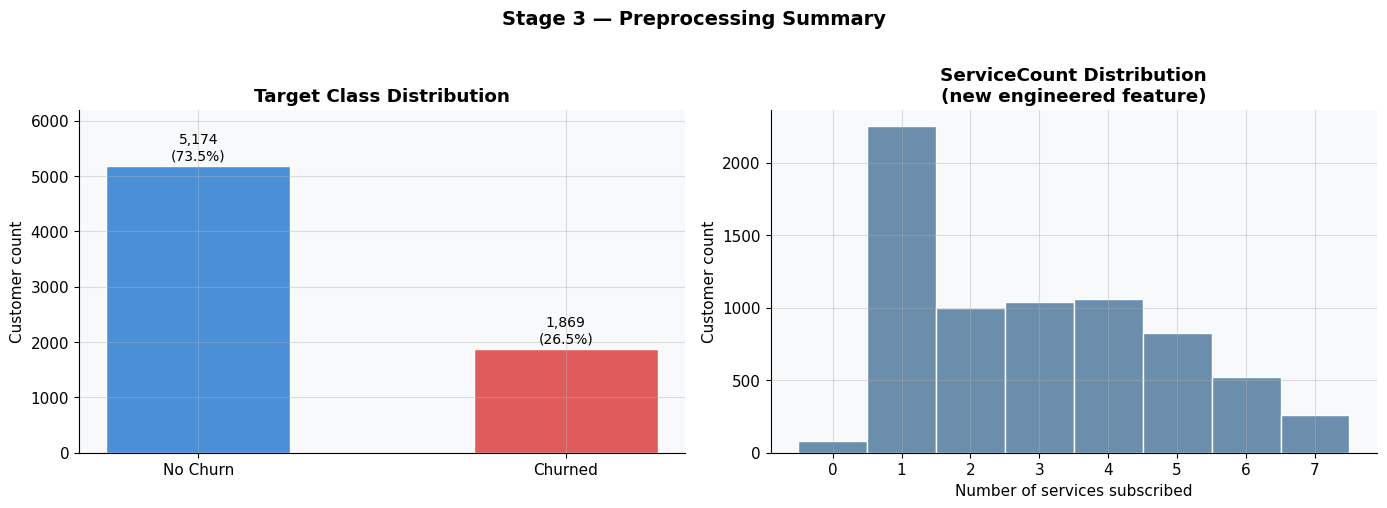

Saved → preprocessing_summary.png


In [2]:
# =============================================================================
# STAGE 3: Data Preprocessing & Cleaning
# Dataset: Telco Customer Churn (IBM Watson / Kaggle)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
PALETTE = {'No': '#4A90D9', 'Yes': '#E05C5C'}

# =============================================================================
# 1. LOAD RAW DATA
# =============================================================================
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("=" * 60)
print("RAW DATA — INITIAL INSPECTION")
print("=" * 60)
print(f"Shape      : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\nColumn dtypes:\n{df_raw.dtypes.to_string()}")
print(f"\nFirst 3 rows:\n{df_raw.head(3).to_string()}")

# =============================================================================
# 2. FIX TotalCharges — stored as string, 11 rows are whitespace
# =============================================================================
# Why: pandas read TotalCharges as object because some entries are " " (space).
#      Those 11 rows all have tenure == 0 (brand-new customers, no bill yet).
#      We fill them with 0.0 — semantically correct and avoids dropping rows.

df = df_raw.copy()

# Convert to numeric; coerce forces non-numeric → NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Identify the 11 affected rows
null_tc_mask = df['TotalCharges'].isnull()
print(f"\n[Fix 1] TotalCharges whitespace rows  : {null_tc_mask.sum()}")
print(f"         All have tenure == 0          : {(df.loc[null_tc_mask, 'tenure'] == 0).all()}")

# Fill NaN with 0 (tenure = 0 → no bill accumulated yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
print(f"         Nulls remaining after fill    : {df['TotalCharges'].isnull().sum()}")

# =============================================================================
# 3. DROP customerID — a unique identifier with zero predictive value
# =============================================================================
df.drop(columns=['customerID'], inplace=True)
print(f"\n[Fix 2] Dropped customerID. Columns now: {df.shape[1]}")

# =============================================================================
# 4. ENCODE TARGET — Churn: Yes → 1, No → 0
# =============================================================================
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"\n[Fix 3] Target encoding:")
print(df['Churn'].value_counts().rename({0: 'No (0)', 1: 'Yes (1)'}))

# =============================================================================
# 5. BINARY CATEGORICAL COLUMNS — encode Yes/No → 1/0
# =============================================================================
binary_yes_no = [
    'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Some of these have a 3rd value ("No internet service" or "No phone service")
# which logically maps to 0 as well — customer does not have the add-on.
for col in binary_yes_no:
    df[col] = df[col].map(lambda x: 1 if x == 'Yes' else 0)

print(f"\n[Fix 4] Binary columns encoded (Yes=1, else=0): {binary_yes_no}")

# gender: Female → 0, Male → 1
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
print("         gender encoded: Female=0, Male=1")

# SeniorCitizen is already 0/1 — no change needed
print("         SeniorCitizen: already 0/1 ✓")

# =============================================================================
# 6. MULTI-CLASS CATEGORICAL — One-Hot Encode
# =============================================================================
# Columns with 3+ meaningful categories that have no inherent order
multi_cat = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines']

# MultipleLines has 3 values: 'No', 'Yes', 'No phone service'
# After one-hot, 'No phone service' becomes its own dummy — that's fine and
# keeps the information that the customer has no phone plan at all.

df = pd.get_dummies(df, columns=multi_cat, drop_first=False)

# Convert all new bool dummies to int
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"\n[Fix 5] One-hot encoded: {multi_cat}")
print(f"         New shape: {df.shape}")
print(f"         New dummy columns: {[c for c in df.columns if any(m in c for m in multi_cat)]}")

# =============================================================================
# 7. FEATURE ENGINEERING
# =============================================================================
# These derived features capture business logic not directly in the raw data.

# 7a. Average monthly charge relative to what they've paid so far
#     High ratio → recent price hike or new high-tier plan
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# 7b. Service count — customers using more services are more embedded
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['ServiceCount'] = df[service_cols].sum(axis=1)

# 7c. Contract risk score — month-to-month is the highest churn-risk contract
#     Ordinal: Month-to-month=2, One year=1, Two year=0
#     (the one-hot dummy is not ordinal, so we add this separately)
if 'Contract_Month-to-month' in df.columns:
    df['ContractRisk'] = (
        df['Contract_Month-to-month'] * 2 +
        df['Contract_One year'] * 1 +
        df['Contract_Two year'] * 0
    )

print(f"\n[Fix 6] Feature engineering:")
print(f"         ChargesPerMonth  — avg spend rate")
print(f"         ServiceCount     — how embedded is the customer (0-7)")
print(f"         ContractRisk     — ordinal contract risk (0=low, 2=high)")

# =============================================================================
# 8. SCALE NUMERICAL FEATURES
# =============================================================================
# Done here for reference; in the modelling notebook, fit scaler ONLY on
# X_train and transform X_test to avoid data leakage.

from sklearn.preprocessing import StandardScaler

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'ChargesPerMonth', 'ServiceCount']

print(f"\n[Fix 7] Columns to scale in modelling stage: {numerical_cols}")
print("         (StandardScaler will be fit on X_train only — not here)")

# =============================================================================
# 9. FINAL DATA SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"\nAll columns:\n{list(df.columns)}")
print(f"\nDescriptive stats (numerical):\n{df[numerical_cols].describe().round(2)}")

# =============================================================================
# 10. SAVE CLEANED DATA
# =============================================================================
df.to_csv('telco_churn_cleaned.csv', index=False)
print("\nSaved → telco_churn_cleaned.csv")

# =============================================================================
# 11. VISUALISE: Before vs After (missing values + dtype fixes)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 3 — Preprocessing Summary', fontsize=14, fontweight='bold', y=1.01)

# -- Panel 1: Class distribution after encoding
churn_counts = df['Churn'].value_counts().rename({0: 'No Churn', 1: 'Churned'})
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=['#4A90D9', '#E05C5C'], width=0.5, edgecolor='white')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Customer count')
for bar, val in zip(bars, churn_counts.values):
    pct = val / churn_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, 6200)

# -- Panel 2: Engineered features distribution
axes[1].hist(df['ServiceCount'], bins=range(0, 9), color='#6B8EAD',
             edgecolor='white', align='left')
axes[1].set_title('ServiceCount Distribution\n(new engineered feature)', fontweight='bold')
axes[1].set_xlabel('Number of services subscribed')
axes[1].set_ylabel('Customer count')
axes[1].set_xticks(range(0, 8))

plt.tight_layout()
plt.savefig('preprocessing_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → preprocessing_summary.png")

EDA

Saved → eda_categorical_drivers.png
Saved → eda_numerical_distributions.png


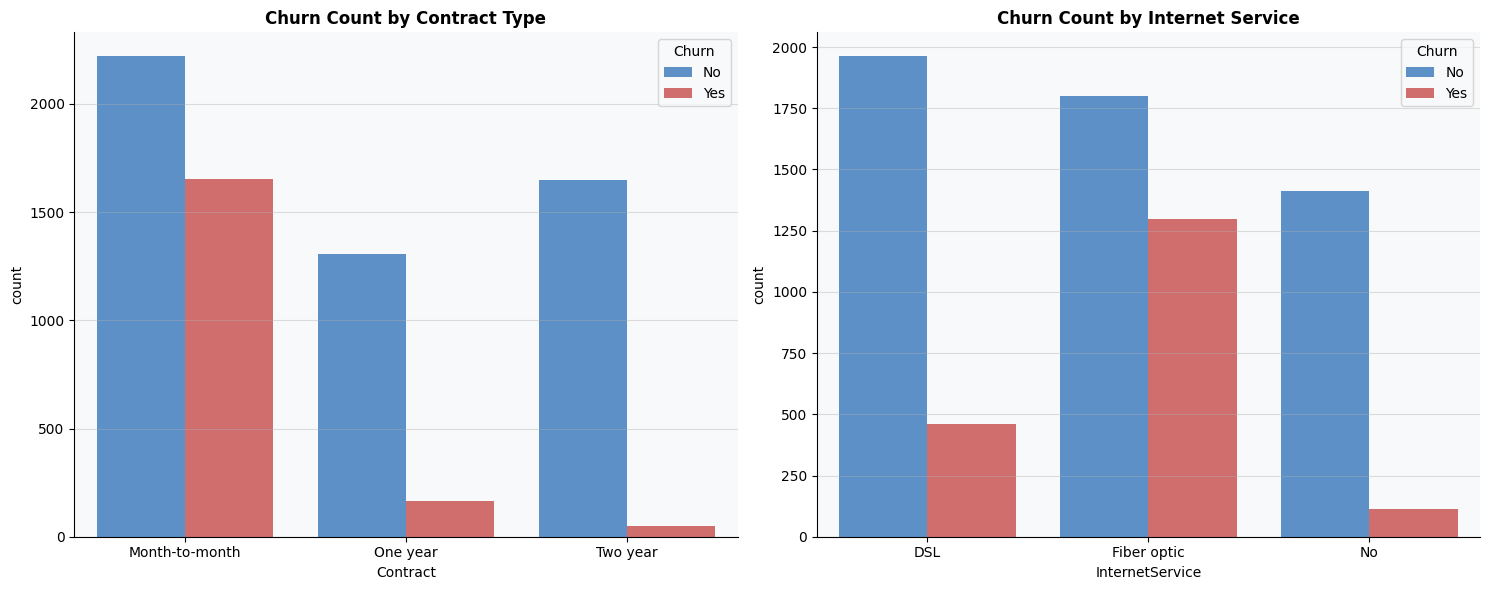

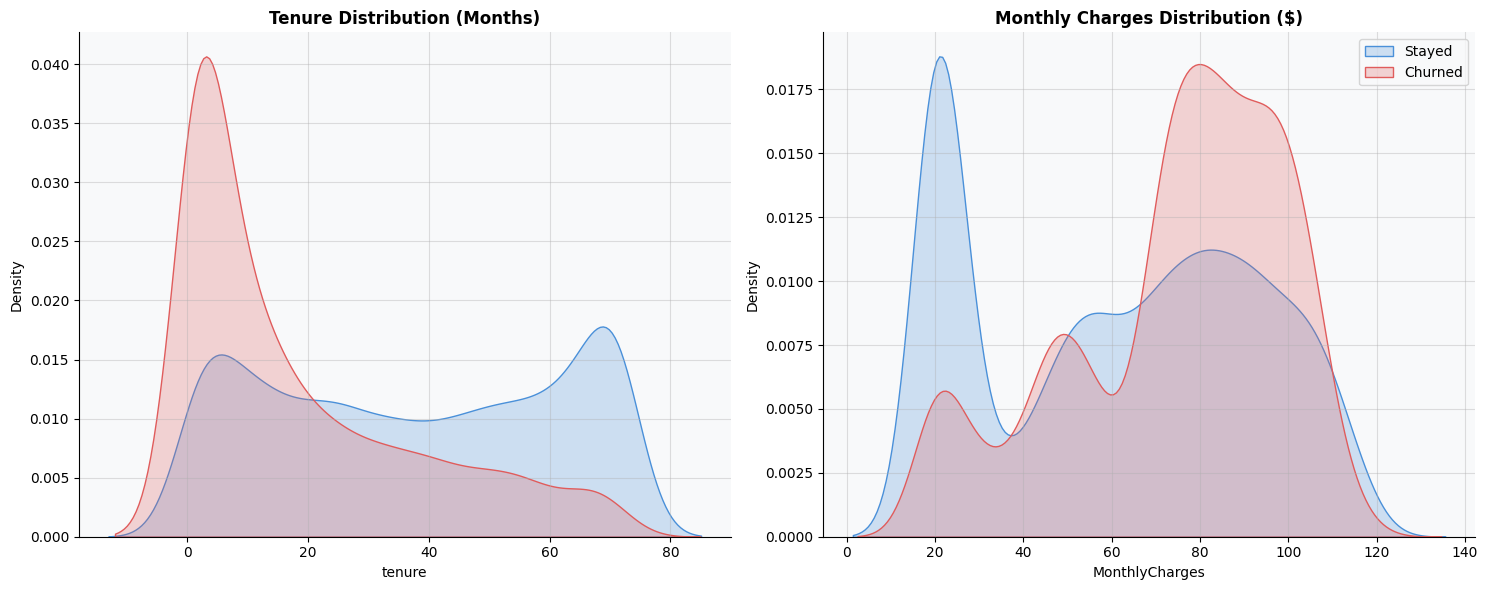

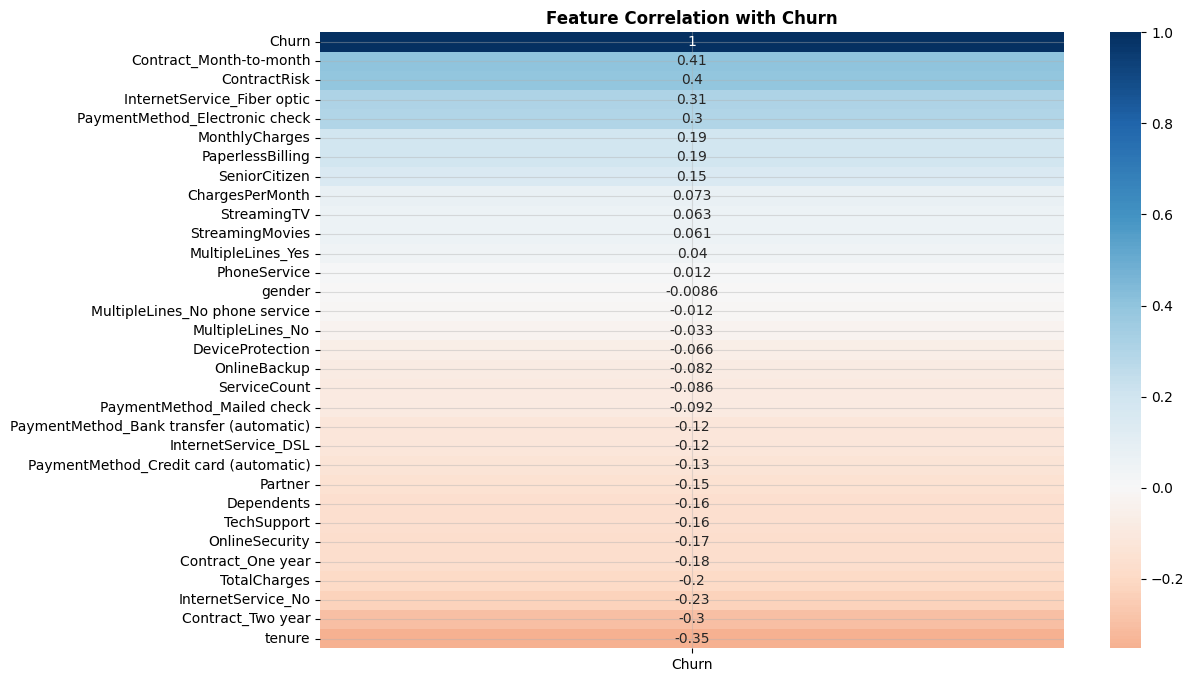


QUICK INSIGHTS
1. Average Tenure of Churned Customers: 18.0 months
2. Average Tenure of Retained Customers: 37.6 months
3. Most Churn happens in 'Month-to-month' contracts.
4. Fiber Optic users have a higher churn rate compared to DSL.


In [3]:
# =============================================================================
# STAGE 4: Exploratory Data Analysis (EDA)
# Purpose: Identify patterns and drivers of customer churn
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Global Plot Settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'font.family':       'sans-serif',
    'font.size':         10,
})
PALETTE = {0: '#4A90D9', 1: '#E05C5C'} # Blue = Stayed, Red = Churned

# 2. Load Data
# We use the cleaned data for correlations and the raw data for readable labels
df = pd.read_csv('telco_churn_cleaned.csv')
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# =============================================================================
# VISUALIZATION 1: Categorical Drivers (Contract & Internet)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Churn by Contract Type
sns.countplot(data=df_raw, x='Contract', hue='Churn', palette=['#4A90D9', '#E05C5C'], ax=axes[0])
axes[0].set_title('Churn Count by Contract Type', fontweight='bold')

# Churn by Internet Service
sns.countplot(data=df_raw, x='InternetService', hue='Churn', palette=['#4A90D9', '#E05C5C'], ax=axes[1])
axes[1].set_title('Churn Count by Internet Service', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_categorical_drivers.png')
print("Saved → eda_categorical_drivers.png")

# =============================================================================
# VISUALIZATION 2: Numerical Distributions (Tenure & Charges)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tenure Distribution
sns.kdeplot(df.loc[df['Churn'] == 0, 'tenure'], shade=True, label='Stayed', ax=axes[0], color='#4A90D9')
sns.kdeplot(df.loc[df['Churn'] == 1, 'tenure'], shade=True, label='Churned', ax=axes[0], color='#E05C5C')
axes[0].set_title('Tenure Distribution (Months)', fontweight='bold')

# Monthly Charges Distribution
sns.kdeplot(df.loc[df['Churn'] == 0, 'MonthlyCharges'], shade=True, label='Stayed', ax=axes[1], color='#4A90D9')
sns.kdeplot(df.loc[df['Churn'] == 1, 'MonthlyCharges'], shade=True, label='Churned', ax=axes[1], color='#E05C5C')
axes[1].set_title('Monthly Charges Distribution ($)', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('eda_numerical_distributions.png')
print("Saved → eda_numerical_distributions.png")

# =============================================================================
# VISUALIZATION 3: Correlation Matrix (Identifying top predictors)
# =============================================================================
plt.figure(figsize=(12, 8))
# Highlighting features that correlate most with Churn
top_corr = df.corr()[['Churn']].sort_values(by='Churn', ascending=False)
sns.heatmap(top_corr, annot=True, cmap='RdBu', center=0)
plt.title('Feature Correlation with Churn', fontweight='bold')
plt.savefig('eda_correlation_heatmap.png')
plt.show()

# =============================================================================
# SUMMARY STATISTICS FOR VIVA / PRESENTATION
# =============================================================================
print("\n" + "="*30)
print("QUICK INSIGHTS")
print("="*30)
print(f"1. Average Tenure of Churned Customers: {df[df['Churn']==1]['tenure'].mean():.1f} months")
print(f"2. Average Tenure of Retained Customers: {df[df['Churn']==0]['tenure'].mean():.1f} months")
print(f"3. Most Churn happens in 'Month-to-month' contracts.")
print(f"4. Fiber Optic users have a higher churn rate compared to DSL.")

SMOTE

In [4]:
# =============================================================================
# STAGE 5: Handling Class Imbalance with SMOTE
# =============================================================================
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Define Features (X) and Target (y)
# Assuming 'df' is your cleaned dataframe from the previous step
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Train-Test Split (CRITICAL STEP)
# We split BEFORE SMOTE so the test set remains realistic and untouched.
# 'stratify=y' keeps the churn ratio same in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original training shape: {y_train.value_counts().to_dict()}")

# 3. Apply SMOTE
# This creates synthetic examples for the 'Churned' class.
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Verification
print("="*30)
print("SMOTE REFINEMENT COMPLETE")
print("="*30)
print(f"Resampled training shape: {pd.Series(y_train_res).value_counts().to_dict()}")
print("Note: Classes are now perfectly balanced at 50/50 for training.")

Original training shape: {0: 4139, 1: 1495}
SMOTE REFINEMENT COMPLETE
Resampled training shape: {0: 4139, 1: 4139}
Note: Classes are now perfectly balanced at 50/50 for training.


Feature Engineering

In [5]:
# =============================================================================
# CELL 1 — PULL SMOTE-BALANCED DATA FROM MEMBER 1
# =============================================================================
# X_train_res, y_train_res  → SMOTE balanced training data
# X_test, y_test            → original test data (untouched)

print("Shape of SMOTE training data :", X_train_res.shape)
print("Class distribution after SMOTE:", dict(pd.Series(y_train_res).value_counts()))
print("Test data shape               :", X_test.shape)

Shape of SMOTE training data : (8278, 31)
Class distribution after SMOTE: {0: np.int64(4139), 1: np.int64(4139)}
Test data shape               : (1409, 31)


In [6]:
# =============================================================================
# CELL 2 — TRAIN RANDOM FOREST
# =============================================================================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators     = 300,
    min_samples_leaf = 4,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

rf_model.fit(X_train_res, y_train_res)

print("=" * 40)
print("Random Forest — Training Complete ✅")
print("=" * 40)

Random Forest — Training Complete ✅


In [7]:
# =============================================================================
# CELL 3 — TRAIN XGBOOST
# =============================================================================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = (y_train_res == 0).sum() / (y_train_res == 1).sum(),
    eval_metric       = 'logloss',
    random_state      = 42,
    use_label_encoder = False
)

xgb_model.fit(X_train_res, y_train_res)

print("=" * 40)
print("XGBoost — Training Complete ✅")
print("=" * 40)

XGBoost — Training Complete ✅


RECALL & ROC-AUC COMPARISON
Random Forest  →  Recall: 0.6203  |  ROC-AUC: 0.8363
XGBoost        →  Recall: 0.6016  |  ROC-AUC: 0.8378


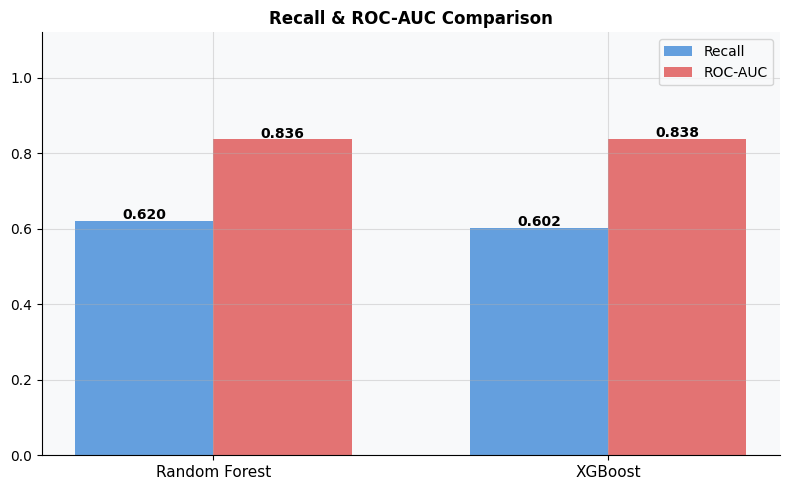

Saved → recall_roc_comparison.png


In [8]:
# =============================================================================
# CELL 4 — COMPARE RECALL & ROC-AUC SCORES
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import recall_score, roc_auc_score

BLUE, RED = '#4A90D9', '#E05C5C'

# Predictions
rf_pred       = rf_model.predict(X_test)
rf_pred_prob  = rf_model.predict_proba(X_test)[:, 1]

xgb_pred      = xgb_model.predict(X_test)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Scores
rf_recall   = recall_score(y_test, rf_pred)
rf_roc      = roc_auc_score(y_test, rf_pred_prob)

xgb_recall  = recall_score(y_test, xgb_pred)
xgb_roc     = roc_auc_score(y_test, xgb_pred_prob)

print("=" * 40)
print("RECALL & ROC-AUC COMPARISON")
print("=" * 40)
print(f"Random Forest  →  Recall: {rf_recall:.4f}  |  ROC-AUC: {rf_roc:.4f}")
print(f"XGBoost        →  Recall: {xgb_recall:.4f}  |  ROC-AUC: {xgb_roc:.4f}")

# Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
models_names = ['Random Forest', 'XGBoost']
recalls  = [rf_recall,  xgb_recall]
roc_aucs = [rf_roc,     xgb_roc]

x     = np.arange(2)
width = 0.35
b1 = ax.bar(x - width/2, recalls,  width, label='Recall',  color=BLUE, alpha=0.85)
b2 = ax.bar(x + width/2, roc_aucs, width, label='ROC-AUC', color=RED,  alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Recall & ROC-AUC Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('recall_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → recall_roc_comparison.png")



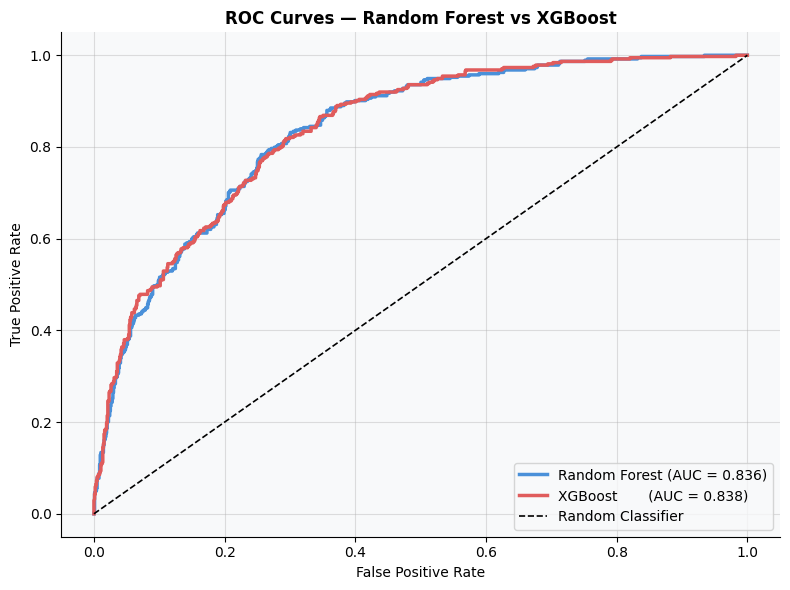

Saved → roc_curves.png


In [9]:
# =============================================================================
# CELL 5 — ROC CURVES
# =============================================================================
from sklearn.metrics import roc_curve

rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_pred_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rf_fpr,  rf_tpr,  lw=2.5, color=BLUE, label=f'Random Forest (AUC = {rf_roc:.3f})')
ax.plot(xgb_fpr, xgb_tpr, lw=2.5, color=RED,  label=f'XGBoost       (AUC = {xgb_roc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Random Forest vs XGBoost', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → roc_curves.png")


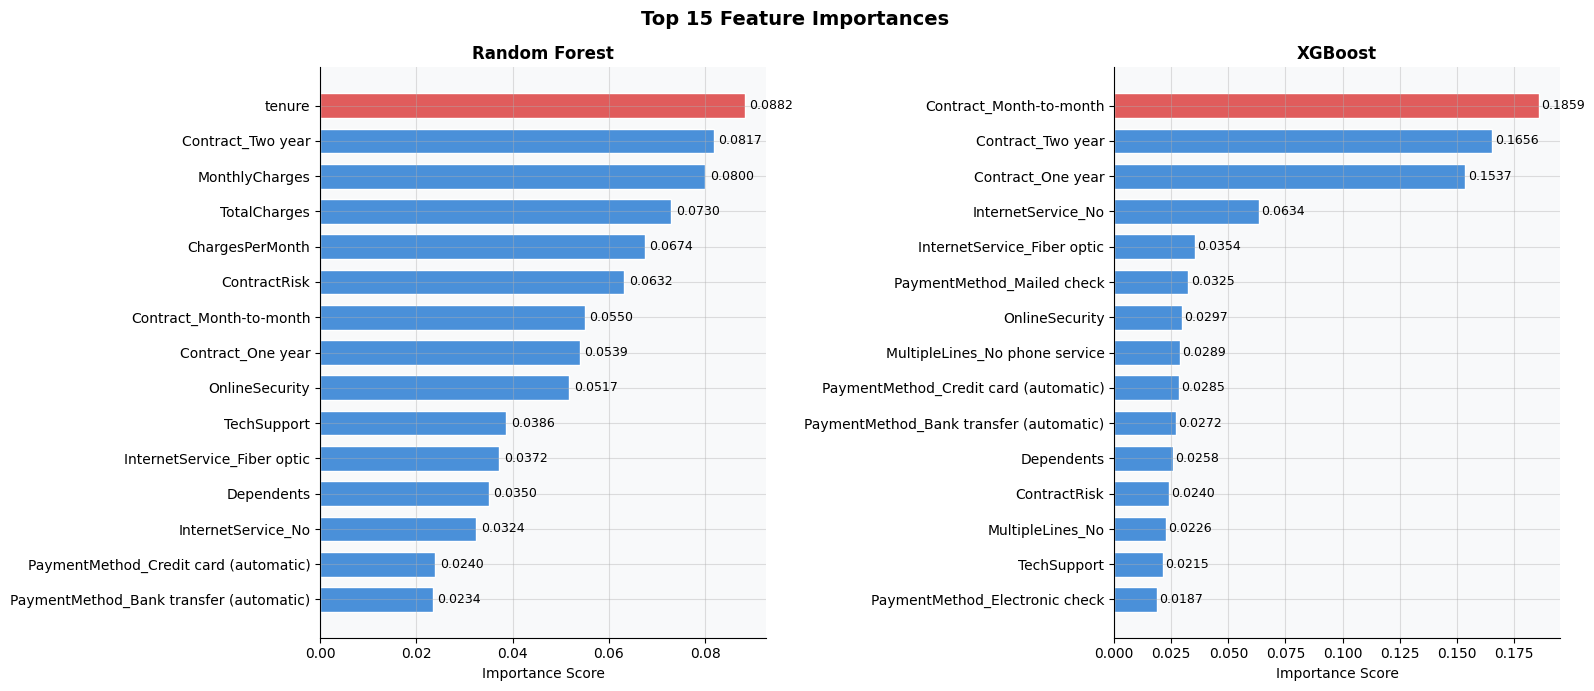

Saved → feature_importance.png


In [10]:
# =============================================================================
# CELL 6 — FEATURE IMPORTANCE PLOT
# =============================================================================
import pandas as pd

feature_names = X_train_res.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 15 Feature Importances', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, [('Random Forest', rf_model), ('XGBoost', xgb_model)]):
    top15 = (pd.Series(model.feature_importances_, index=feature_names)
               .sort_values(ascending=False)
               .head(15)
               .iloc[::-1])

    bar_colors = [RED if i == len(top15)-1 else BLUE for i in range(len(top15))]
    ax.barh(top15.index, top15.values, color=bar_colors, edgecolor='white', height=0.7)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, val in enumerate(top15.values):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → feature_importance.png")